In [ ]:
import sqlite3

import pandas as pd

import matplotlib.pyplot as plt

import warnings         #to ignore more warnings and show only  lines of warnings needed  example traceback
warnings.filterwarnings('ignore')



In [ ]:
df=pd.read_csv('student_performance.csv')

In [ ]:
df.shape[1]

13

In [ ]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [ ]:
connection=sqlite3.connect('college.db')  #create a dtabse
cursor=connection.cursor()#cursor is like a pen thta write sql query into databse

df.to_sql(
    'students',    #Name of the table to craate tablein databse iin new database that open
  connection,    #which databse to want to use
  if_exists='replace',  #If 'students' table exists,replace it
  index=False    #if index false not given then it consider as 0 to 29 for this table so we give false
)

#without to_sql() we need to write 30 insert statement
cursor.execute("Select count(*) from students")

count=cursor.fetchone()[0]  #fetchone retrives the first  result row,[0] retrives first value from thta row

print("College.db created")
print(f"Table student s has {count} rows ")


College.db created
Table student s has 30 rows 


In [ ]:
cursor.execute("select * from students")

In [ ]:
#pragma is a special sqlite command (not standard sql)
#table_info() shows the structure of a table

cursor.execute("PRAGMA table_info(students)")
col_info=cursor.fetchall()

for col in col_info:
  print(f"{col[1]:<25} {col[2]:<12}")

student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:
def run_query(sql,description=""):
  res=pd.read_sql_query(sql,connection)
  print(res.to_string(index=False))
  if description:
    print(description)
  print(res)

In [ ]:
run_query("select * from students", description="Students Table:")

 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 55                     78              Delhi            2023
       1004    Sneha Reddy   20 Female       Mechanical         2          70             80             75                 48                     95          Hyderabad            2023
       1005     Arjun Nair   19   Male Computer Science         2          

In [ ]:
run_query("select name,math_score,science_score,english_score,programming_score from students limit 5 offset 25",description="")

          name  math_score  science_score  english_score  programming_score
    Rekha Nair          72             77             73                 63
 Gaurav Shukla          84             79             75                 87
 Sunita Pillai          60             65             68                 39
    Nitin Jain          75             76             70                 50
Akanksha Yadav          91             93             87                 94
             name  math_score  science_score  english_score  programming_score
0      Rekha Nair          72             77             73                 63
1   Gaurav Shukla          84             79             75                 87
2   Sunita Pillai          60             65             68                 39
3      Nitin Jain          75             76             70                 50
4  Akanksha Yadav          91             93             87                 94


In [ ]:
run_query("select name,department,math_score from students order by math_score desc limit 5",description="")




          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4  Swati Kulkarni  Computer Science          90


In [ ]:
run_query("select name,department,math_score from students order by programming_score desc limit 5",description="")

          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
   Divya Singh Computer Science          88
             name        department  math_score
0      Ananya Das  Computer Science          95
1     Tanvi Mehta  Computer Science          93
2      Arjun Nair  Computer Science          92
3  Akanksha Yadav  Computer Science          91
4     Divya Singh  Computer Science          88


In [ ]:
run_query("select name,department,math_score,programming_score  from students  where programming_score >=55 and programming_score <=75",description="")

         name  department  math_score  programming_score
  Rohit Verma Electronics          65                 55
  Vikram Iyer Electronics          80                 72
 Ritu Agarwal Electronics          87                 69
Harish Pillai Electronics          64                 58
   Rekha Nair Electronics          72                 63
            name   department  math_score  programming_score
0    Rohit Verma  Electronics          65                 55
1    Vikram Iyer  Electronics          80                 72
2   Ritu Agarwal  Electronics          87                 69
3  Harish Pillai  Electronics          64                 58
4     Rekha Nair  Electronics          72                 63


In [ ]:
run_query("select name,department,math_score,programming_score  from students  where programming_score between 55 and 75",description="")

         name  department  math_score  programming_score
  Rohit Verma Electronics          65                 55
  Vikram Iyer Electronics          80                 72
 Ritu Agarwal Electronics          87                 69
Harish Pillai Electronics          64                 58
   Rekha Nair Electronics          72                 63
            name   department  math_score  programming_score
0    Rohit Verma  Electronics          65                 55
1    Vikram Iyer  Electronics          80                 72
2   Ritu Agarwal  Electronics          87                 69
3  Harish Pillai  Electronics          64                 58
4     Rekha Nair  Electronics          72                 63


In [ ]:
run_query("select name,department,math_score,programming_score,attendance_percentage from students  where department='Computer Science' order by programming_score desc",description="")


          name       department  math_score  programming_score  attendance_percentage
    Ananya Das Computer Science          95                 97                     98
   Tanvi Mehta Computer Science          93                 96                     97
    Arjun Nair Computer Science          92                 95                     90
Akanksha Yadav Computer Science          91                 94                     95
   Divya Singh Computer Science          88                 93                     96
Swati Kulkarni Computer Science          90                 92                     94
  Aarav Sharma Computer Science          85                 91                     92
     Amit Bose Computer Science          86                 89                     91
    Suresh Rao Computer Science          83                 88                     88
 Gaurav Shukla Computer Science          84                 87                     87
  Nisha Kapoor Computer Science          79           

In [ ]:
run_query("select name,department,math_score,programming_score,attendance_percentage from students  where department<>'Electronics' order by programming_score desc limit 1",description="")


      name       department  math_score  programming_score  attendance_percentage
Ananya Das Computer Science          95                 97                     98
         name        department  math_score  programming_score  \
0  Ananya Das  Computer Science          95                 97   

   attendance_percentage  
0                     98  


In [ ]:
run_query("SELECT student_id,name,attendance_percentage FROM students WHERE attendance_percentage not in (SELECT attendance_percentage FROM students WHERE attendance_percentage <= 80);",description="")

 student_id           name  attendance_percentage
       1001   Aarav Sharma                     92
       1002    Priya Patel                     87
       1004    Sneha Reddy                     95
       1005     Arjun Nair                     90
       1007    Kiran Kumar                     85
       1008    Divya Singh                     96
       1010     Ananya Das                     98
       1011    Vikram Iyer                     83
       1013     Suresh Rao                     88
       1014  Kavya Nambiar                     91
       1016   Ritu Agarwal                     93
       1018 Swati Kulkarni                     94
       1020   Nisha Kapoor                     89
       1022    Tanvi Mehta                     97
       1024  Preeti Saxena                     86
       1025      Amit Bose                     91
       1026     Rekha Nair                     82
       1027  Gaurav Shukla                     87
       1029     Nitin Jain                     84


In [ ]:
dept_data={
    'dept_code':['CS','EC','ME','CE'],
    'dept_name':['Computer Science','Electronics','Mechanical','Civil'],
    'hod_name' :['Dr.Sharma','Dr.Reddy','Dr.Patel','Dr.Kumar'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}

#we define python direcotry :keys=column names,values=lists of data
dept_df=pd.DataFrame(dept_data)

#pd.dataframe() converts a dictinary into a dataframe
#each key incomes a cloumn

print(dept_df.to_string(index=False))


dept_map={
    'Computer Science':'CS',
    'Electronics':'EC',
    'Mechanical':'ME',
    'Civil':'CE'
}

df['dept_code']=df['department'].map(dept_map)

# Save the dept_df DataFrame to the database as 'department' table
dept_df.to_sql('department', connection, if_exists='replace', index=False)

df.to_sql('students',connection,if_exists='replace',index=False)

run_query("select * from students")

dept_code        dept_name  hod_name  established  intake
       CS Computer Science Dr.Sharma         1985      60
       EC      Electronics  Dr.Reddy         1988      60
       ME       Mechanical  Dr.Patel         1972      60
       CE            Civil  Dr.Kumar         1965      60
 student_id           name  age gender       department  semester  math_score  science_score  english_score  programming_score  attendance_percentage               city  admission_year dept_code
       1001   Aarav Sharma   19   Male Computer Science         2          85             78             72                 91                     92             Mumbai            2023      None
       1002    Priya Patel   20 Female Computer Science         2          76             82             88                 79                     87          Ahmedabad            2023      None
       1003    Rohit Verma   19   Male      Electronics         2          65             74             61                 5

(None,)

In [ ]:
query_join="""
Select
s.name,s.math_score,d.dept_name,d.hod_name,d.established
from students as s
inner join department as d
on s.dept_code=d.dept_code
order by s.math_score desc
limit 8
"""

In [ ]:
run_query(query_join,description="Join Query Results (with corrected dept_code):")

          name  math_score  dept_name hod_name  established
 Preeti Saxena          77 Mechanical Dr.Patel         1972
    Nitin Jain          75 Mechanical Dr.Patel         1972
 Kavya Nambiar          74 Mechanical Dr.Patel         1972
   Kiran Kumar          73      Civil Dr.Kumar         1965
   Sneha Reddy          70 Mechanical Dr.Patel         1972
Deepak Chauhan          68 Mechanical Dr.Patel         1972
   Pooja Gupta          67      Civil Dr.Kumar         1965
  Rahul Mishra          62 Mechanical Dr.Patel         1972
Join Query Results:
             name  math_score   dept_name  hod_name  established
0   Preeti Saxena          77  Mechanical  Dr.Patel         1972
1      Nitin Jain          75  Mechanical  Dr.Patel         1972
2   Kavya Nambiar          74  Mechanical  Dr.Patel         1972
3     Kiran Kumar          73       Civil  Dr.Kumar         1965
4     Sneha Reddy          70  Mechanical  Dr.Patel         1972
5  Deepak Chauhan          68  Mechanical  Dr.Pate

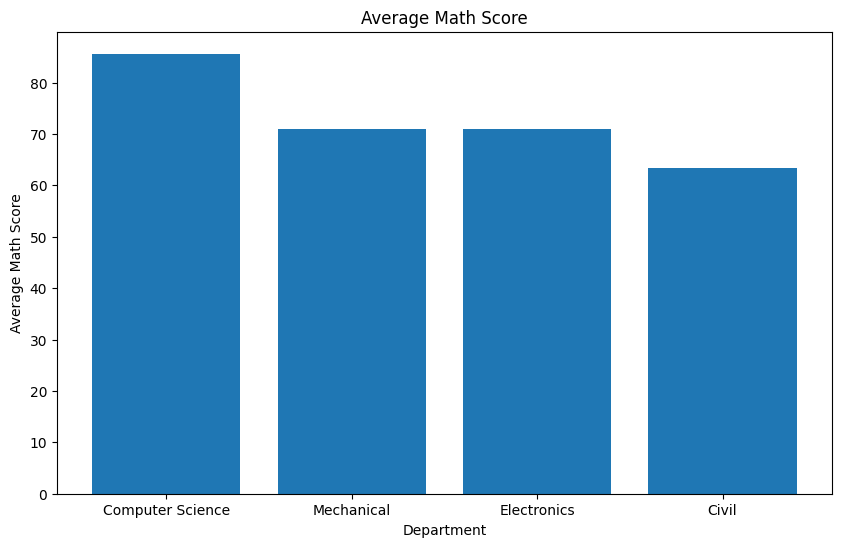

In [ ]:
chart1_sql = """
SELECT department, ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC;
"""
chart1_df = pd.read_sql_query(chart1_sql,connection)
fig , ax = plt.subplots(figsize=(10,6))
ax.bar(chart1_df['department'],chart1_df['avg_math'])
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score')
plt.show()